In [1]:
import rospy
rospy.init_node("data_node")

# Clock
Domyślnym źródłem czasu w ROS jest czas systemowy z komputera. Niestety w przypadku, gdy chcemy odtwarzać dane w czasie przyspieszonym, spowolnionym lub mieć większą kontrolę nad czasem konieczne jest zastosowanie symulowanego zegara czasu. W przypadku odtwarzania danych z czujnika ważniejsze jest by timestamp z jakim są zapisane dane odnosił się do czasu z jakim były one zbierane, a nie czasem systemu komputera na którym będą odtwarzane dane np. położenie enkodera w danych chwilach czasowych. W tej sytuacji dla różnych zegarów czasu wyznaczone prędkości obrotowe na podstawie zebranych danych byłyby różne, gdyby dla tych samych danych odnosił się do nich inny timestamp.

Do użycia symulowanego czasu przez node'a konieczne jest wcześniejsze ustawienie parametru w ROS:

/use_sim_time na True.

W ROS w danej chwili może być aktywny maksymalnie tylko jeden serwer czasu. Serwerem czasu może być dowolny node, który będzie publikował na topicu /clock wiadomość typu roslib/Clock.

Podczas odtwarzania rosbaga może okazać się, że brakuje źródła czasu. W takiej sytuacji polecenie należy uruchomić używając

--clock

In [2]:
# zwraca aktualny czas ROS jako rospy.Time 
# jesli używany jest symulowany czas to zwracana wartość pierwszej wiadomosci wynosi 0 co 
# oznacza, że czas nie jest znany.
now = rospy.get_rostime()
print(now)

1648570454377341032


In [3]:
# zwraca aktualny czas w sekundach,
rospy.get_time()

1648570455.2163224

In [4]:
print(rospy.Time.now())

1648570456086607456


In [5]:
# uśpienie na zadany czas w sekundach
d = rospy.Duration(2,0)
rospy.sleep(d)

# Bag
Jest to format danych przechowujący informacje o wiadomościach, które zostały wybrane do zarejestrowania w trakcie działania jakiegoś procesu np. monitorowanie zmiany położenia w czasie, zbieranie danych z czujników. Zebrane dane mogą być później użyte do testowania różnych algorytmów np. do wyznaczania odometrii na podstawie fuzji danych z sensorów, testowania różnych parametrów algorytmów do mapowania terenu.

Do utworzenia bag'a wykorzystywane jest narzędzie rosbag umożliwiające rejestrowanie wiadomości ROS. Takie podejście umożliwia odtwarzanie i dostarczanie danych do systemu w taki sam sposób w jaki się pojawiają przy użyciu node'ów. 

Dostępne komendy dla polecenia rosbag.

In [14]:
!rosbag --help

Usage: rosbag <subcommand> [options] [args]

A bag is a file format in ROS for storing ROS message data. The rosbag command can record, replay and manipulate bags.

Available subcommands:
   check  	Determine whether a bag is playable in the current system, or if it can be migrated.
   compress  	Compress one or more bag files.
   decompress  	Decompress one or more bag files.
   decrypt  	Decrypt one or more bag files.
   encrypt  	Encrypt one or more bag files.
   filter  	Filter the contents of the bag.
   fix  	Repair the messages in a bag file so that it can be played in the current system.
   help  
   info  	Summarize the contents of one or more bag files.
   play  	Play back the contents of one or more bag files in a time-synchronized fashion.
   record  	Record a bag file with the contents of specified topics.
   reindex  	Reindexes one or more bag files.

For additional information, see http://wiki.ros.org/rosbag



### Rosbag record - rejestrowanie danych

Szczegółowe informacje o dostępnych możliwościach polecenia można znaleźć na stronie.

http://wiki.ros.org/rosbag/Commandline

Rejestrowane mogą być nie tylko wszystkie dane jednocześnie tak ja się pojawiają w systemie, ale mamy możliwość wybrania sposobu jak mają być zarejestrowane. Można zarejestrować m.in.:

- pojedyncze wiadomości (oddzielne nazwy topicow)

- wiadomości spełniające okreslone kryteria (-e (regex), -x (exclude_regex) z podanym kryterium filtracji)

- rosbaga o określonym czasie trwania (--duration)

- rosbaga o określonym rozmiarze (--size)

- podział baga na mniejszy plik gdy czas trwania lub rozmiar zostanie przekroczony (--split)

- rozbaga o określonym prefixie w nazwie (-o) oraz o podanej nazwie (-O)

- maksymalna liczba zarejestrowanych danych, starsze pliki będą kasowane (--max-splits)

- topici z określonego node'a (--node)


In [7]:
# Pomoc do polecenia od rejestrowania danych
!rosbag record --help

Usage: rosbag record TOPIC1 [TOPIC2 TOPIC3 ...]

Record a bag file with the contents of specified topics.

Options:
  -h, --help            show this help message and exit
  -a, --all             record all topics
  -e, --regex           match topics using regular expressions
  -p, --publish         publish a msg when the record begin
  -x EXCLUDE_REGEX, --exclude=EXCLUDE_REGEX
                        exclude topics matching the follow regular expression
                        (subtracts from -a or regex)
  -q, --quiet           suppress console output
  -o PREFIX, --output-prefix=PREFIX
                        prepend PREFIX to beginning of bag name (name will
                        always end with date stamp)
  -O NAME, --output-name=NAME
                        record to bag with name NAME.bag
  --split               split the bag when maximum size or duration is reached
  --max-splits=MAX_SPLITS
                        Keep a maximum of N bag files, when reaching the
            

W najprostszej wersji można zarejestrować wszystkie pojawiające się topic'i w systemie

In [ ]:
!rosbag record -a

Tylko wybrane topic'i

In [ ]:
!rosbag record /turtle1/cmd_vel

Zapis rosbaga o określonym czasie trwania.

In [ ]:
!rosbag record --duration=30 /laser

Z dzieleniem rosbaga, gdy przekroczy dany rozmiar lub długość czasu rejestracji. Czas może być podany z typem jednostki. Brak jednostki odnosi się do sekund (m-minuty, h-godziny).

In [ ]:
!rosbag record --split --size=2048 /odometry
!rosbag record --split --duration=30m /odometry

Zapis tylko X ostatnich rosbagów. Każdy kolejny nadmiarowy powoduje usunięcie najstarszego zarejestrowanego rosbaga.

In [ ]:
!rosbag record --split --size 1024 --max-splits 3 /laser

Zapis wszystkich topic'ów dla node'a o podanej nazwie /sterowanie

In [ ]:
!rosbag record --node=/sterowanie

Zarejestrowanie bag'a o podanej nazwie. Wykorzystany zostanie do dalszych ćwiczeń. Zarejestrowany zostanie z czasem trwania, gdyż przerwanie rejestrowania z poziomu jupyter notebook najczęściej wymaga reindeksowania.

In [27]:
!rosbag record -O TSR.bag -a --duration=10

[ INFO] [1648573146.726067281]: Recording to 'TSR.bag'.
[ INFO] [1648573146.727721321]: Subscribing to /rosout_agg
[ INFO] [1648573146.733427238]: Subscribing to /rosout
[ INFO] [1648573146.738749928]: Subscribing to /robot1/pose
[ INFO] [1648573146.748119928]: Subscribing to /robot1/color_sensor
[ INFO] [1648573146.759233846]: Subscribing to /robot2/pose
[ INFO] [1648573146.763819576]: Subscribing to /robot2/color_sensor
[ INFO] [1648573146.767861468]: Subscribing to /robot3/pose
[ INFO] [1648573146.772111888]: Subscribing to /robot3/color_sensor
[ INFO] [1648573146.776091075]: Subscribing to /robot1/cmd_vel
[ INFO] [1648573146.780152559]: Subscribing to /robot2/cmd_vel
[ INFO] [1648573146.785666269]: Subscribing to /robot3/cmd_vel


#### UWAGA
W trakcie zapisu rosbaga przy niewlaściwym jego zamknięciu może zdarzyć się, że będzie miał on rozszerzenie active. Takiego rosbaga nie można odtworzyć, ale można dokonać reindeksowania, które rozwiązuje problem. Oryginalny rosbag zapisany zostanie jako kopia pod tą samą nazwą z rozszerzeniem .orig.bag.

In [20]:
!rosbag reindex "2022-03-29-16-22-58.bag.active"

Skipping 2022-03-29-16-22-58.bag.active. Backup path 2022-03-29-16-22-58.bag.orig.active already exists.


### Rosbag info - informacj o rosbagu
Zawiera podstawowe informacje o rosbagu tj. wersja, czas trwania, data i godzina rozpoczęcia i zakończenia, rozmiar, typy zarejestrowanych wiadomości i topic'i.

In [23]:
!rosbag info "TSR.bag"

path:        TSR.bag
version:     2.0
duration:    5.8s
start:       Mar 29 2022 16:43:20.71 (1648572200.71)
end:         Mar 29 2022 16:43:26.54 (1648572206.54)
size:        1.2 MB
messages:    12835
compression: none [2/2 chunks]
types:       geometry_msgs/Twist [9f195f881246fdfa2798d1d3eebca84a]
             rosgraph_msgs/Log   [acffd30cd6b6de30f120938c17c593fb]
             turtlesim/Color     [353891e354491c51aabe32df673fb446]
             turtlesim/Pose      [863b248d5016ca62ea2e895ae5265cf9]
topics:      /robot1/cmd_vel        3632 msgs    : geometry_msgs/Twist
             /robot1/color_sensor    354 msgs    : turtlesim/Color    
             /robot1/pose            354 msgs    : turtlesim/Pose     
             /robot2/cmd_vel        3628 msgs    : geometry_msgs/Twist
             /robot2/color_sensor    354 msgs    : turtlesim/Color    
             /robot2/pose            354 msgs    : turtlesim/Pose     
             /robot3/cmd_vel        3442 msgs    : geometry_msgs/Twist

### Rosbag play - odtwarzanie rosbaga
Do odtwarzanie rosbaga wykorzystanie zarejestrowany wcześniej TSR.bag.

In [26]:
!rosbag play --help

Usage: rosbag play BAGFILE1 [BAGFILE2 BAGFILE3 ...]

Play back the contents of one or more bag files in a time-synchronized
fashion.

Options:
  -h, --help            show this help message and exit
  -p PREFIX, --prefix=PREFIX
                        prefix all output topics
  -q, --quiet           suppress console output
  -i, --immediate       play back all messages without waiting
  --pause               start in paused mode
  --queue=SIZE          use an outgoing queue of size SIZE (defaults to 100)
  --clock               publish the clock time
  --hz=HZ               use a frequency of HZ when publishing clock time
                        (default: 100)
  -d SEC, --delay=SEC   sleep SEC seconds after every advertise call (to allow
                        subscribers to connect)
  -r FACTOR, --rate=FACTOR
                        multiply the publish rate by FACTOR
  -s SEC, --start=SEC   start SEC seconds into the bag files
  -u SEC, --duration=SEC
                        play on

**Przed odtworzeniem rosbaga należy zrestartować symulację turtlesim do poziomu bazowego i dodać roboty:**

In [28]:
!rosservice call /reset
!rosservice call /kill turtle1
!rosservice call /spawn 5.5 4 0 robot1
!rosservice call /spawn 5.5 2.5 0 robot2
!rosservice call /spawn 5.5 1 0 robot3



name: "robot1"
name: "robot2"
name: "robot3"


Odtwarzanie całego rosbaga o podanej nazwie

In [29]:
!rosbag play "TSR.bag"

[ INFO] [1648573332.239703061]: Opening TSR.bag

Waiting 0.2 seconds after advertising topics... done.

Hit space to toggle paused, or 's' to step.
 [RUNNING]  Bag Time: 1648573156.722132   Duration: 9.931607 / 9.932007               
Done.


Po zrestartowaniu i uruchomieniu symulacji z odtworzonymi danymi roboty poruszały się po okręgu. Jednak nie zawsze zarejestrowane sterowanie przekazane ponownie do tego samego robota pozwoli uzyskać taki sam efekt. Wpływ na różnice ma czas wysłania komend.

### Zapis danych z rosbaga do pliku .yaml
Do zarejestrowania danych z poziomu terminala w lokalizacji z rosbagiem TSR.bag wywołać polecenie, które natychmiast odtworzy wszystkie zarejestrowane wiadomości w tym wymaganą /robot1/cmd_vel.

rosbag play --immmediate TSR.bag

In [81]:
!rostopic echo /robot1/cmd_vel | tee velocities.yaml

## Python Odczyt i analiza danych
Link do wiki zawierającego więcej szczegółowych informacji i przykładów.
http://wiki.ros.org/rosbag/Cookbook

Do obsługi rosbagów w Python służy biblioteka rosbag.

In [36]:
import rosbag

In [37]:
# utworzenie obiektu Bag, obsługuje dane zawarte w rosbagu.
bag_name = "TSR.bag"
bag = rosbag.Bag(bag_name) 

In [38]:
# wyświetlenie surowych danych o topic'ach i ich typach
print(bag.get_type_and_topic_info())

TypesAndTopicsTuple(msg_types={'geometry_msgs/Twist': '9f195f881246fdfa2798d1d3eebca84a', 'rosgraph_msgs/Log': 'acffd30cd6b6de30f120938c17c593fb', 'turtlesim/Color': '353891e354491c51aabe32df673fb446', 'turtlesim/Pose': '863b248d5016ca62ea2e895ae5265cf9'}, topics={'/robot1/cmd_vel': TopicTuple(msg_type='geometry_msgs/Twist', message_count=4680, connections=1, frequency=14315.03071672355), '/robot1/color_sensor': TopicTuple(msg_type='turtlesim/Color', message_count=611, connections=1, frequency=63.58715311204263), '/robot1/pose': TopicTuple(msg_type='turtlesim/Pose', message_count=611, connections=1, frequency=63.59727676608391), '/robot2/cmd_vel': TopicTuple(msg_type='geometry_msgs/Twist', message_count=4741, connections=1, frequency=13957.750415973378), '/robot2/color_sensor': TopicTuple(msg_type='turtlesim/Color', message_count=611, connections=1, frequency=63.60692133877254), '/robot2/pose': TopicTuple(msg_type='turtlesim/Pose', message_count=611, connections=1, frequency=63.6030631

In [43]:
# Wyświetlenie zarejestrowanych topic'ów
for data in bag.get_type_and_topic_info()[1].keys():
    print(data)

/robot1/cmd_vel
/robot1/color_sensor
/robot1/pose
/robot2/cmd_vel
/robot2/color_sensor
/robot2/pose
/robot3/cmd_vel
/robot3/color_sensor
/robot3/pose
/rosout


In [46]:
# Wyświetlenie listy topic'ów wraz z typami
for data in bag.get_type_and_topic_info()[1].keys():
    print(data + "   " + bag.get_type_and_topic_info()[1][data][0])

/robot1/cmd_vel   geometry_msgs/Twist
/robot1/color_sensor   turtlesim/Color
/robot1/pose   turtlesim/Pose
/robot2/cmd_vel   geometry_msgs/Twist
/robot2/color_sensor   turtlesim/Color
/robot2/pose   turtlesim/Pose
/robot3/cmd_vel   geometry_msgs/Twist
/robot3/color_sensor   turtlesim/Color
/robot3/pose   turtlesim/Pose
/rosout   rosgraph_msgs/Log


In [76]:
# Odczyt pierwszej wiadomości z rosbaga. Metoda read_messages() odpowiada za odczyt kolejnych
# zarejestrowanych wiadomości z każdą kolejną wykonaną iteracją pętli for. Odczytane wartości
# po wykonaniu iteracji zapisywane są kolejno w zmiennych:
# - topic (nazwa topicu typu str)
# - msg (wiadomość ROS, dla cmd_vel jest to typ geometry_msgs/Twist)
# - t (czas w ROS, w którym zarejestrowana była wiadomośc typu rostime.Time)

tsr_rosbag = rosbag.Bag("TSR.bag")
for topic, msg, t in tsr_rosbag.read_messages():
    if topic == "/robot1/cmd_vel":
        print(topic)
        print(type(topic))
        print("-------")
        print(msg)
        print(type(msg))
        print("-------")
        print(t)
        print(type(t))
        break

/robot1/cmd_vel
<class 'str'>
-------
linear: 
  x: 1.0
  y: 0.0
  z: 0.0
angular: 
  x: 0.0
  y: 0.0
  z: 1.0
<class 'tmpuns35hcm._geometry_msgs__Twist'>
-------
1648573147023494493
<class 'rospy.rostime.Time'>


# Python - logowanie danych
Informacje wyświetlanie i publikowane przez node'y w trakcie pracy systemu. Pozwalają zorientować się co aktualnie jest wykonywane i czy wszystko działa prawidłowo.

In [ ]:
rospy.logdebug(msg, *args)  # informacje do debugowania, niepotrzebne dla użytkownika w trakcie
# prawidłowej pracy
rospy.logwarn(msg, *args)  # ostrzeżenie
rospy.loginfo(msg, *args)  # informacja
rospy.logerr(msg, *args)  # błąd możliwy do rozwiązania przy pomocy recovery
rospy.logfatal(msg, *args)  # błąd krytyczny, nie da się go naprawić

# RQT_BAG
Narzędzie graficzne do nagrywania i wizualizacji danych z rosbaga. 

Uruchomienie:

In [ ]:
!rosrun rqt_bag rqt_bag

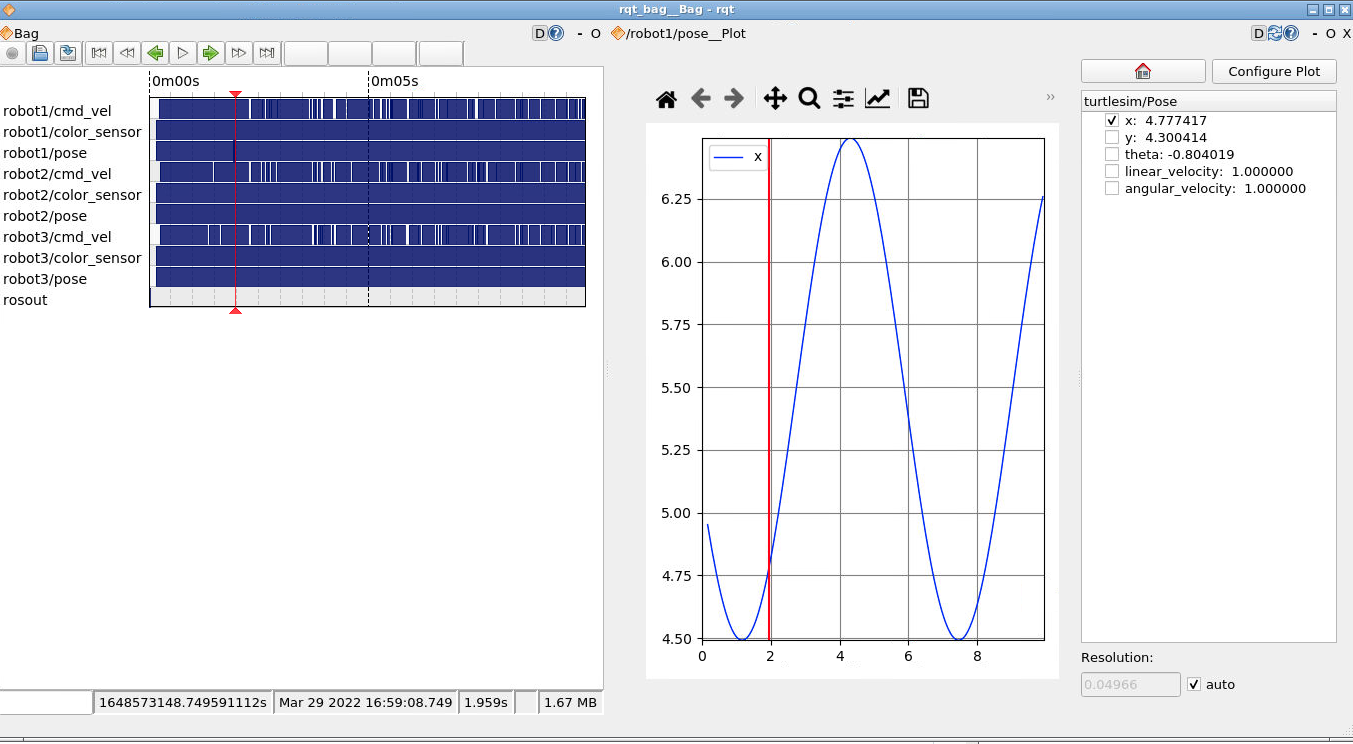

# RQT_TOP
Do monitorowania aktualnie działających nodów. Możliwość filtracji i wyłączania niektórych node'ów.

Uruchomienie:

In [ ]:
!rosrun rqt_top rqt_top

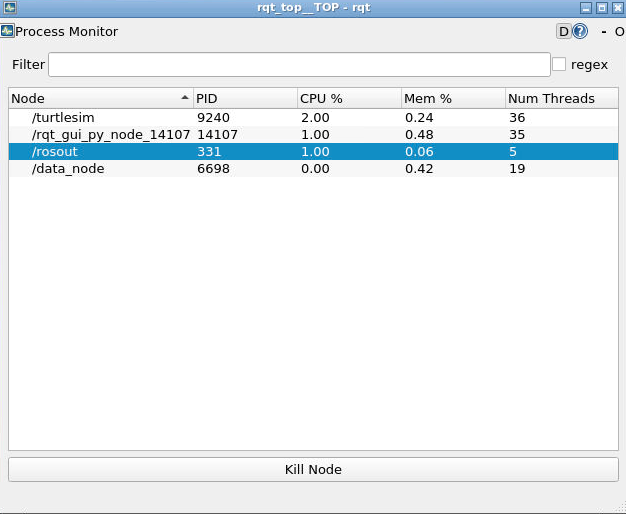

# RQT_MSG
Graficzne narzędzie do podglądu zainstalowanych w systemie dostępnych z punku widzenia ROS
typów wiadomości dla topic'ów. Umożliwia podgląd struktury wiadomości. 

Uruchomienie:

In [ ]:
!rosrun rqt_msg rqt_msg

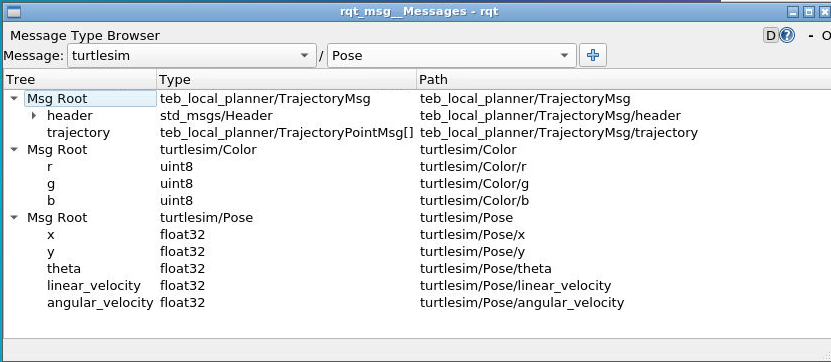

# RQT_TOPIC
Graficzne narzędzie do monitorowania wybranych topiców, które są aktywne w systemie. 

Uruchomienie:

In [2]:
!rosrun rqt_topic rqt_topic

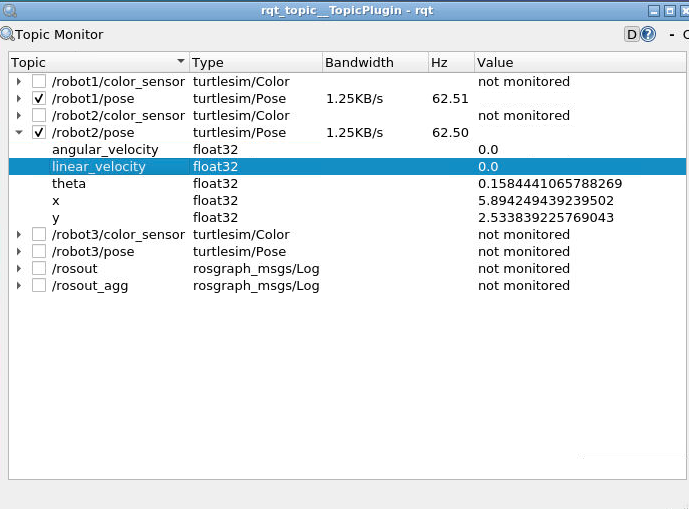

# RQT_PUBLISHER
Narzędzie pozwalające na publikowanie wiadomości z interfejsu graficznego. Do wyboru jest nazwa topicu, typ i częstotliwość z jaką ma być wysyłana wiadomość. Po kliknięciu prawym przyciskiem na wiadomośc można wysłać ją tylko raz do robota. 

Uruchomienie:

In [80]:
!rosrun rqt_publisher rqt_publisher

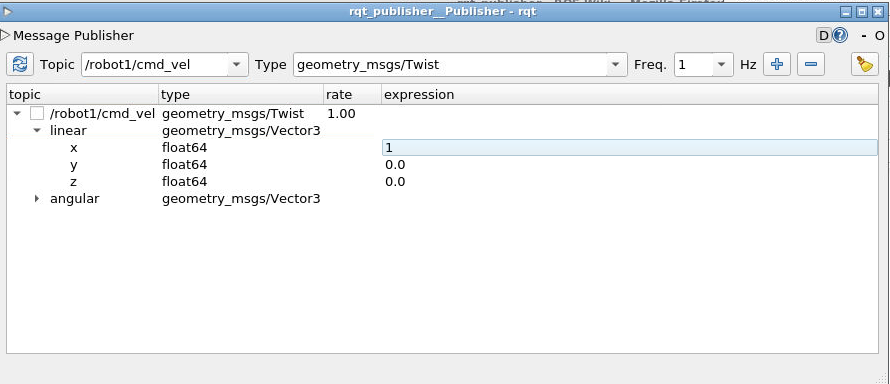

# RQT_SRV
Graficzne narzędzie do podglądu dostępnych w systemie typów wiadomości serwisowych z podziałem na zapytania (request) i odpowiedzi (response). 

Uruchomienie:

In [ ]:
!rosrun rqt_srv rqt_srv

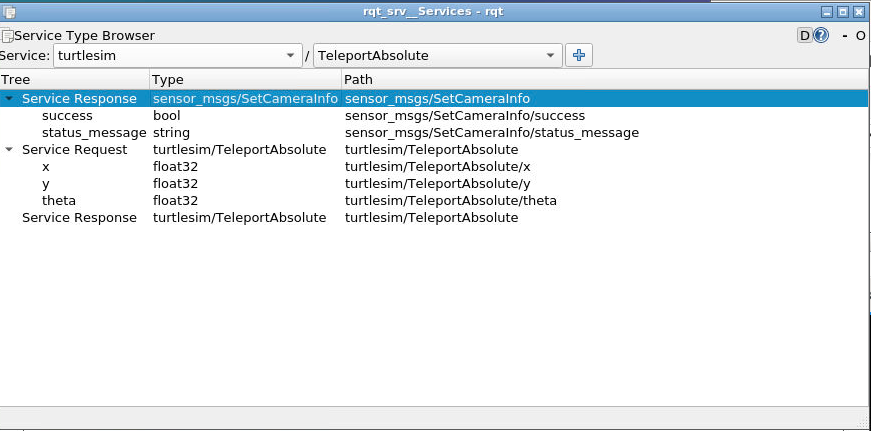

# RQT_SERVICE_CALLER
Narzędzie graficzne do wysyłania zapytań klienta na serwer. 

Uruchomienie:

In [ ]:
!rosrun rqt_service_caller rqt_service_caller 

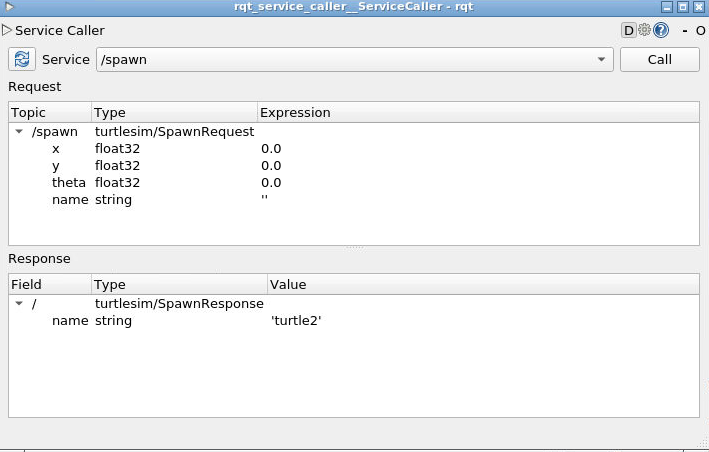

# RQT_LOGGER
Graficzne narzędzie do podglądu dostępnych w systemie dla różnych nodów loggerów danych na różnym poziomie błędów og krytycznych, po debugowanie czy zwykłe informacje. 

Uruchomienie:

In [ ]:
!rosrun rqt_logger_level rqt_logger_level

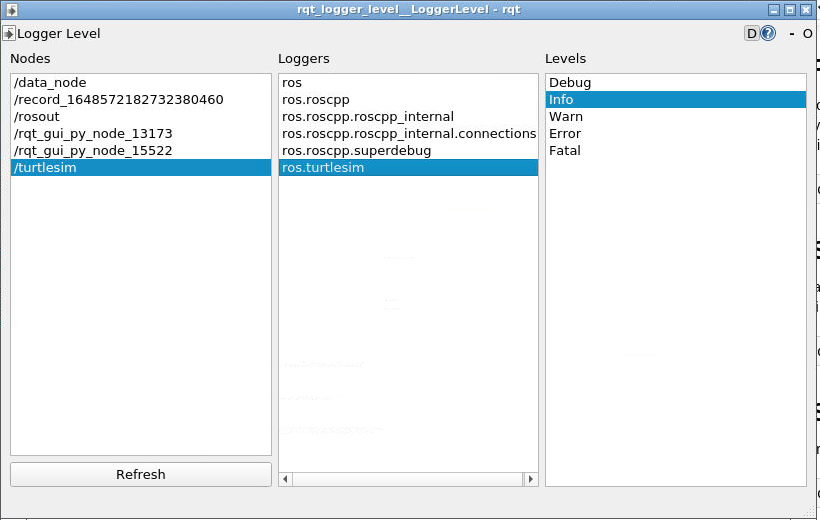